New York Bus delay and Breakdown

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [12]:
# Importing the dataset
df = pd.read_csv('Bus_Breakdown_and_Delays.csv', thousands=',' )

Data exploration

In [123]:
df.head(5)

,School_Year,Busbreakdown_ID,Run_Type,Bus_No,Route_Number,Reason,Schools_Serviced,Occurred_On,Created_On,Boro,...,How_Long_Delayed,Number_Of_Students_On_The_Bus,Has_Contractor_Notified_Schools,Has_Contractor_Notified_Parents,Have_You_Alerted_OPT,Informed_On,Incident_Number,Last_Updated_On,Breakdown_or_Running_Late,School_Age_or_PreK
0,2015-2016,1227538,Special Ed AM Run,2621,J711,Heavy Traffic,75003,2015-11-05 08:10:00,2015-11-05 08:12:00,New Jersey,...,NaN,11,Yes,No,Yes,2015-11-05 08:12:00,NaN,2015-11-05 08:12:14,Running Late,School-Age
1,2015-2016,1227539,Special Ed AM Run,1260,M351,Heavy Traffic,06716,2015-11-05 08:10:00,2015-11-05 08:12:00,Manhattan,...,20MNS,2,Yes,Yes,No,2015-11-05 08:12:00,NaN,2015-11-05 08:13:34,Running Late,School-Age
2,2015-2016,1227540,Pre-K/EI,418,3,Heavy Traffic,C445,2015-11-05 08:09:00,2015-11-05 08:13:00,Bronx,...,15MIN,8,Yes,Yes,Yes,2015-11-05 08:13:00,NaN,2015-11-05 08:13:22,Running Late,Pre-K
3,2015-2016,1227541,Special Ed AM Run,4522,M271,Heavy Traffic,02699,2015-11-05 08:12:00,2015-11-05 08:14:00,Manhattan,...,15 MIN,6,No,No,No,2015-11-05 08:14:00,NaN,2015-11-05 08:14:04,Running Late,School-Age
4,2015-2016,1227542,Special Ed AM Run,3124,M373,Heavy Traffic,02116,2015-11-05 08:13:00,2015-11-05 08:14:00,Manhattan,...,NaN,6,No,No,No,2015-11-05 08:14:00,NaN,2015-11-05 08:14:08,Running Late,School-Age


In [16]:
#Parse the dates
def lookup(a):
    dates = {date:pd.to_datetime(date) for date in a.unique()}
    return a.map(dates)

df['Informed_On'] = lookup(df['Informed_On'])
df['Occurred_On'] = lookup(df['Occurred_On'])
df['Created_On'] = lookup(df['Created_On'])
df['Last_Updated_On'] = lookup(df['Last_Updated_On'])

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373799 entries, 0 to 373798
Data columns (total 21 columns):
School_Year                        373799 non-null object
Busbreakdown_ID                    373799 non-null int64
Run_Type                           373796 non-null object
Bus_No                             373789 non-null object
Route_Number                       373792 non-null object
Reason                             373797 non-null object
Schools_Serviced                   373792 non-null object
Occurred_On                        373799 non-null datetime64[ns]
Created_On                         373799 non-null datetime64[ns]
Boro                               362635 non-null object
Bus_Company_Name                   373799 non-null object
How_Long_Delayed                   330518 non-null object
Number_Of_Students_On_The_Bus      373799 non-null int64
Has_Contractor_Notified_Schools    373799 non-null object
Has_Contractor_Notified_Parents    373799 non-null object
Have_

In [34]:
df.head(5)

,School_Year,Busbreakdown_ID,Run_Type,Bus_No,Route_Number,Reason,Schools_Serviced,Occurred_On,Created_On,Boro,...,How_Long_Delayed,Number_Of_Students_On_The_Bus,Has_Contractor_Notified_Schools,Has_Contractor_Notified_Parents,Have_You_Alerted_OPT,Informed_On,Incident_Number,Last_Updated_On,Breakdown_or_Running_Late,School_Age_or_PreK
0,2015-2016,1227538,Special Ed AM Run,2621,J711,Heavy Traffic,75003,2015-11-05 08:10:00,2015-11-05 08:12:00,New Jersey,...,NaN,11,Yes,No,Yes,2015-11-05 08:12:00,NaN,2015-11-05 08:12:14,Running Late,School-Age
1,2015-2016,1227539,Special Ed AM Run,1260,M351,Heavy Traffic,06716,2015-11-05 08:10:00,2015-11-05 08:12:00,Manhattan,...,20MNS,2,Yes,Yes,No,2015-11-05 08:12:00,NaN,2015-11-05 08:13:34,Running Late,School-Age
2,2015-2016,1227540,Pre-K/EI,418,3,Heavy Traffic,C445,2015-11-05 08:09:00,2015-11-05 08:13:00,Bronx,...,15MIN,8,Yes,Yes,Yes,2015-11-05 08:13:00,NaN,2015-11-05 08:13:22,Running Late,Pre-K
3,2015-2016,1227541,Special Ed AM Run,4522,M271,Heavy Traffic,02699,2015-11-05 08:12:00,2015-11-05 08:14:00,Manhattan,...,15 MIN,6,No,No,No,2015-11-05 08:14:00,NaN,2015-11-05 08:14:04,Running Late,School-Age
4,2015-2016,1227542,Special Ed AM Run,3124,M373,Heavy Traffic,02116,2015-11-05 08:13:00,2015-11-05 08:14:00,Manhattan,...,NaN,6,No,No,No,2015-11-05 08:14:00,NaN,2015-11-05 08:14:08,Running Late,School-Age


In [35]:
df.columns

Index(['School_Year', 'Busbreakdown_ID', 'Run_Type', 'Bus_No', 'Route_Number',
       'Reason', 'Schools_Serviced', 'Occurred_On', 'Created_On', 'Boro',
       'Bus_Company_Name', 'How_Long_Delayed', 'Number_Of_Students_On_The_Bus',
       'Has_Contractor_Notified_Schools', 'Has_Contractor_Notified_Parents',
       'Have_You_Alerted_OPT', 'Informed_On', 'Incident_Number',
       'Last_Updated_On', 'Breakdown_or_Running_Late', 'School_Age_or_PreK'],
      dtype='object')

In [41]:
print(df['School_Year'].unique())

['2015-2016' '2017-2018' '2018-2019' '2016-2017' '2019-2020']


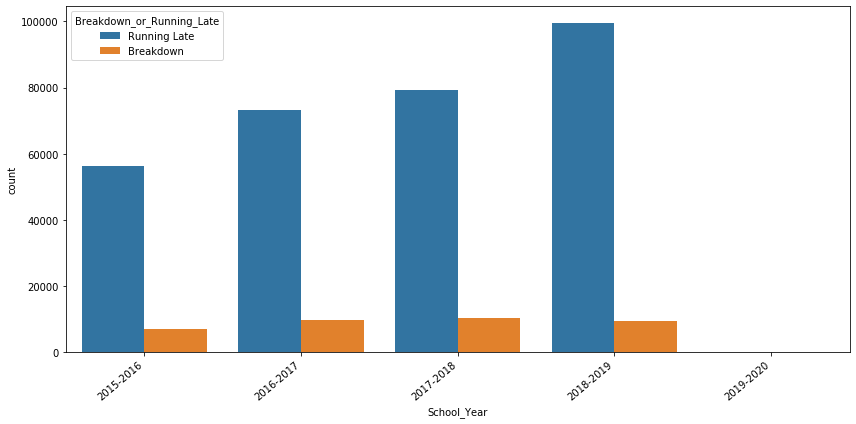

In [68]:
#Visualize number bus delay in each school year in the given data  - recall 2019/2020 school complete yet
plt.figure(figsize=(12,6))
ordered_year = ['2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020']
ax = sns.countplot(x= 'School_Year', data=df, hue = 'Breakdown_or_Running_Late', order = ordered_year)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
plt.tight_layout()
plt.show()

In [52]:
#Since 2019/2020 school year is not complete yet, drop the school. A school year starts in September every year. 
df.drop(df[df['School_Year']=='2019-2020'].index, inplace=True)

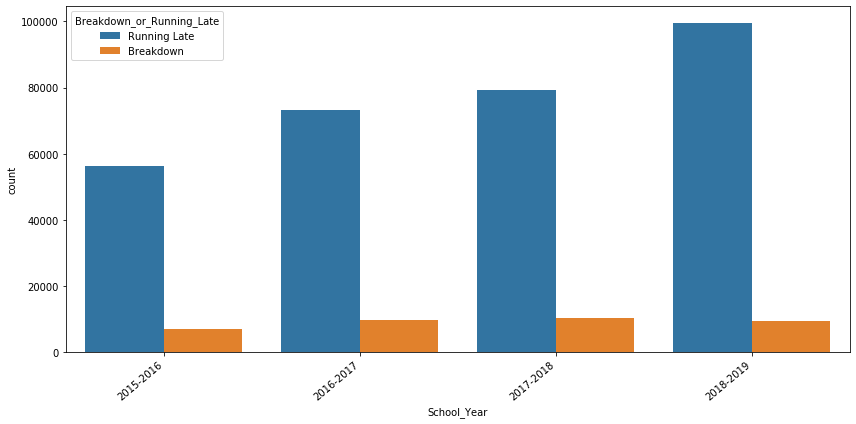

In [69]:
plt.figure(figsize=(12,6))
ordered_year = ['2015-2016', '2016-2017', '2017-2018', '2018-2019']
ax = sns.countplot(x= 'School_Year', data=df, hue = 'Breakdown_or_Running_Late', order = ordered_year)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
plt.tight_layout()
plt.show()

In [90]:
##Check the reasons for delays
df_reason['Reason'].unique() #check for unique reasons

array(['Heavy Traffic', 'Flat Tire', 'Other', 'Won`t Start',
       'Mechanical Problem', 'Problem Run', 'Accident',
       'Late return from Field Trip', 'Delayed by School',
       'Weather Conditions', nan], dtype=object)

In [95]:
ordered_reason = ['Heavy Traffic', 'Other', 'Mechanical Problem', 
                  'Won`t Start', 'Flat Tire', 'Weather Conditions', 
                  'Late return from Field Trip', 'Problem Run', 'Accident',
                  'Delayed by School'] #create a list to arrange the reasons from the highest to lowest. 
                    #we are doing this manually because we have nan values, so sorted function won't work

From graph above it is cleary NYC bus delays have been growing over the past 4 years, for other reasons than breakdowns. It will be interestig to explore reasons for delays 

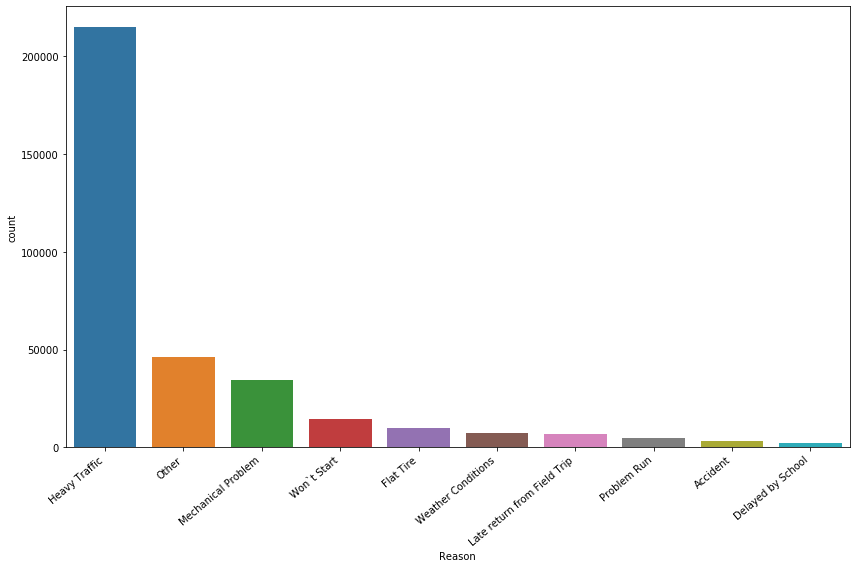

In [114]:
#Check the reasons for delays
plt.figure(figsize=(12,8))
ax = sns.countplot(x= 'Reason', data=df, order = ordered_reason)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
plt.tight_layout()
plt.show()

Majority of the overall buses delay seems to be caused by heavy traffic. 

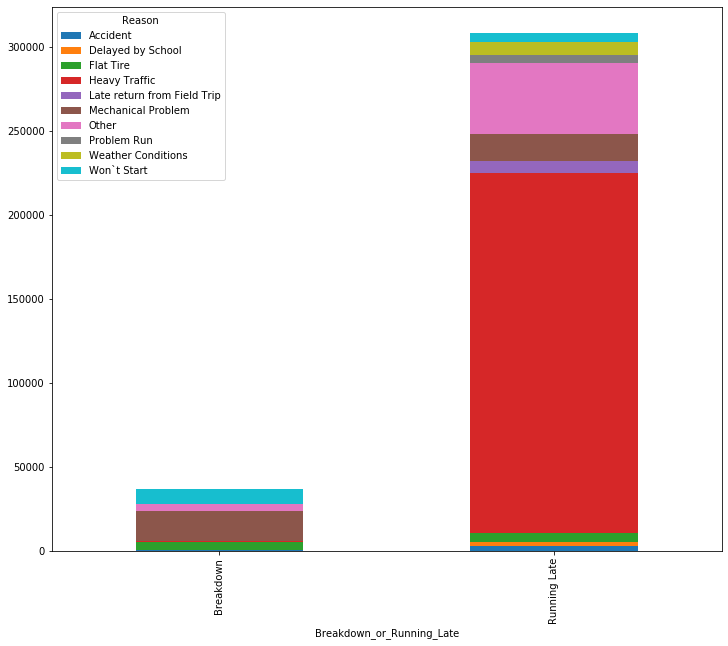

In [124]:
# let's compare reasons for delays for buses running late and breakdown 
df_plot = df.groupby(['Reason', 'Breakdown_or_Running_Late']).size().reset_index().pivot(columns='Reason', 
                                                                                        index='Breakdown_or_Running_Late', 
                                                                                        values=0)
df_plot.plot(kind='bar', stacked=True)
plt.gcf().set_size_inches(12, 10)

From graph above, majority of breakdowns of buses are caused by mechanical problems, while majority of buses that running late they are delayed by heavy trafic. This is not suprising given NYC traffic nature

In [ ]:
df[['School_Year', ]]

In [7]:
df.columns

Index(['School_Year', 'Busbreakdown_ID', 'Run_Type', 'Bus_No', 'Route_Number',
       'Reason', 'Schools_Serviced', 'Occurred_On', 'Created_On', 'Boro',
       'Bus_Company_Name', 'How_Long_Delayed', 'Number_Of_Students_On_The_Bus',
       'Has_Contractor_Notified_Schools', 'Has_Contractor_Notified_Parents',
       'Have_You_Alerted_OPT', 'Informed_On', 'Incident_Number',
       'Last_Updated_On', 'Breakdown_or_Running_Late', 'School_Age_or_PreK'],
      dtype='object')

Data preprocesing

In [31]:
df.isnull().sum()

School_Year                             0
Busbreakdown_ID                         0
Run_Type                                3
Bus_No                                 10
Route_Number                            7
Reason                                  2
Schools_Serviced                        7
Occurred_On                             0
Created_On                              0
Boro                                11164
Bus_Company_Name                        0
How_Long_Delayed                    43281
Number_Of_Students_On_The_Bus           0
Has_Contractor_Notified_Schools         0
Has_Contractor_Notified_Parents         0
Have_You_Alerted_OPT                    0
Informed_On                             0
Incident_Number                    363713
Last_Updated_On                         0
Breakdown_or_Running_Late               0
School_Age_or_PreK                      0
dtype: int64

In [1]:
#Dealing with missing values